# Retail Sales — Exploratory Data Analysis

**Objective:** Perform a thorough EDA on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** `retail_sales_data.csv` — 5,000 order-level transactions spanning Jan 2023 – Dec 2024, covering customer demographics, product categories, pricing, discounts, region, payment method, and post-purchase rating.

**Tech stack:** Python, pandas, matplotlib, seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)


## 1. Load Dataset & Initial Inspection

In [2]:
df = pd.read_csv("retail_sales_data.csv", parse_dates=["OrderDate"])
df.head()


,OrderID,OrderDate,CustomerID,CustomerAge,Gender,Region,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,GrossSales,NetSales,PaymentMethod,CustomerRating
0,ORD100000,2023-01-01,CUST00908,37.0,Female,East,Electronics,Bluetooth Speaker,2,136.70,10,273.40,246.06,Credit Card,3.0
1,ORD100001,2023-01-01,CUST00126,27.0,Female,Central,Home & Kitchen,Cutlery Set,1,80.88,10,80.88,72.79,Debit Card,3.0
2,ORD100002,2023-01-01,CUST00511,48.0,Male,South,Electronics,Laptop Stand,1,22.36,0,22.36,22.36,Cash on Delivery,4.0
3,ORD100003,2023-01-01,CUST00130,38.0,Male,West,Electronics,Bluetooth Speaker,1,154.23,0,154.23,154.23,Credit Card,4.0
4,ORD100004,2023-01-01,CUST01040,40.0,Male,North,Sports & Outdoors,Dumbbell Set,1,151.54,5,151.54,143.96,Cash on Delivery,4.0


In [3]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print()
df.info()


Shape: 5000 rows x 15 columns

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          5000 non-null   str           
 1   OrderDate        5000 non-null   datetime64[us]
 2   CustomerID       5000 non-null   str           
 3   CustomerAge      4900 non-null   float64       
 4   Gender           5000 non-null   str           
 5   Region           4900 non-null   str           
 6   ProductCategory  5000 non-null   str           
 7   ProductName      5000 non-null   str           
 8   Quantity         5000 non-null   int64         
 9   UnitPrice        5000 non-null   float64       
 10  DiscountPercent  5000 non-null   int64         
 11  GrossSales       5000 non-null   float64       
 12  NetSales         5000 non-null   float64       
 13  PaymentMethod    5000 non-null   str           
 14  CustomerRating   490

In [4]:
null_summary = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().sum() / len(df) * 100).round(2)
})
null_summary[null_summary["null_count"] > 0].sort_values("null_count", ascending=False)


,null_count,null_pct
CustomerAge,100,2.0
Region,100,2.0
CustomerRating,100,2.0


**Observations:**
- The dataset contains 5,000 transaction records across 15 columns spanning two full years (2023–2024).
- Column types are appropriate: `OrderDate` is datetime, numeric fields (`Quantity`, `UnitPrice`, `NetSales`, etc.) are correctly typed as int/float, and categorical fields (`Gender`, `Region`, `ProductCategory`, `PaymentMethod`) are objects.
- Missing values are limited to three columns — `CustomerAge`, `Region`, and `CustomerRating` — each at ~2% of records. This is low enough that we can either impute (median for age, mode for region, median for rating) or drop rows for specific analyses without materially affecting results. We'll impute where needed rather than drop, to preserve sample size for revenue calculations.


In [5]:
# Impute missing values sensibly for downstream analysis
df["CustomerAge"] = df["CustomerAge"].fillna(df["CustomerAge"].median())
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])
df["CustomerRating"] = df["CustomerRating"].fillna(df["CustomerRating"].median())

df.isnull().sum().sum()  # confirm 0 remaining


np.int64(0)

## 2. Descriptive Statistics

In [6]:
numeric_cols = ["CustomerAge", "Quantity", "UnitPrice", "DiscountPercent",
                "GrossSales", "NetSales", "CustomerRating"]

desc = df[numeric_cols].describe().T
desc["median"] = df[numeric_cols].median()
desc["mode"] = df[numeric_cols].mode().iloc[0]
desc = desc[["mean", "median", "mode", "std", "min", "25%", "50%", "75%", "max"]]
desc.round(2)


,mean,median,mode,std,min,25%,50%,75%,max
CustomerAge,35.04,35.00,18.00,11.33,18.0,27.00,35.00,43.00,72.00
Quantity,1.48,1.00,1.00,0.87,1.0,1.00,1.00,2.00,5.00
UnitPrice,89.98,77.76,20.11,59.75,6.0,40.01,77.76,126.90,249.93
DiscountPercent,4.15,0.00,0.00,6.79,0.0,0.00,0.00,5.00,25.00
GrossSales,134.31,95.82,51.94,133.05,6.0,50.74,95.82,171.40,1233.15
NetSales,128.73,90.86,23.81,128.39,4.5,48.37,90.86,164.21,1178.15
CustomerRating,3.60,4.00,4.00,0.91,1.0,3.00,4.00,4.00,5.00


**Observations:**
- Average order net sales is a useful benchmark for AOV (average order value) tracking; the gap between mean and median `NetSales` indicates a right-skewed distribution — a smaller number of high-value orders pull the average upward.
- `Quantity` per order is heavily concentrated at 1–2 units (mode = 1), typical of retail baskets where most customers buy single items.
- `DiscountPercent` has a mode of 0, meaning most transactions occur at full price — discounting is the exception rather than the norm, which is good for margin health.
- `CustomerAge` centers in the mid-30s with a standard deviation of roughly a decade, suggesting a working-age customer base rather than a niche youth or senior segment.
- `CustomerRating` averages around 4 out of 5, indicating generally positive customer sentiment.


## 3. Time Series Analysis: Monthly & Quarterly Sales Trends

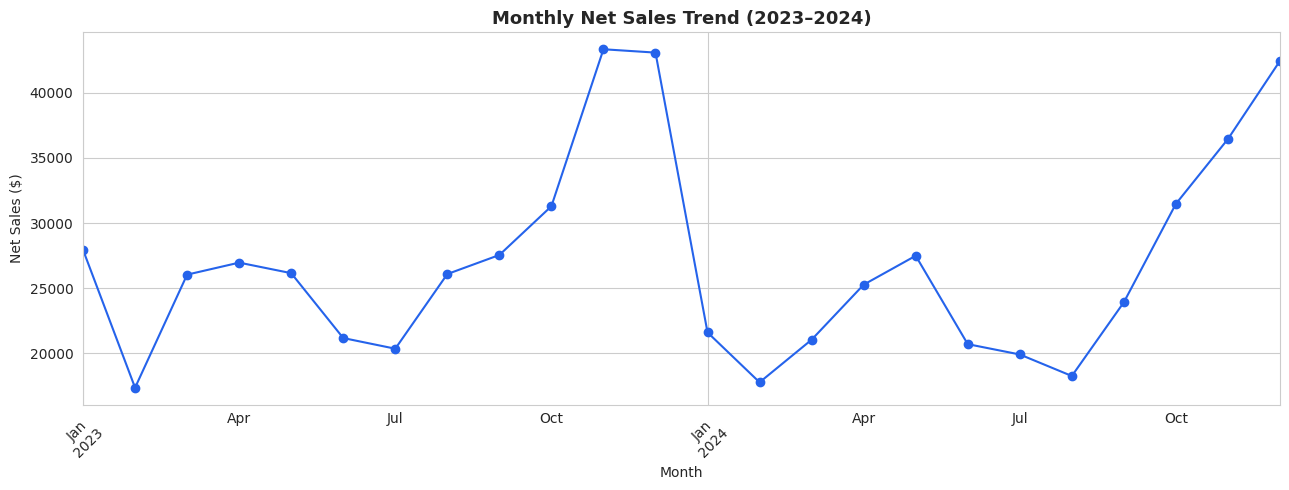

In [7]:
df["YearMonth"] = df["OrderDate"].dt.to_period("M")
df["YearQuarter"] = df["OrderDate"].dt.to_period("Q")

monthly_sales = df.groupby("YearMonth")["NetSales"].sum()
quarterly_sales = df.groupby("YearQuarter")["NetSales"].sum()

fig, ax = plt.subplots(figsize=(13, 5))
monthly_sales.plot(kind="line", marker="o", ax=ax, color="#2563eb")
ax.set_title("Monthly Net Sales Trend (2023–2024)")
ax.set_xlabel("Month")
ax.set_ylabel("Net Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


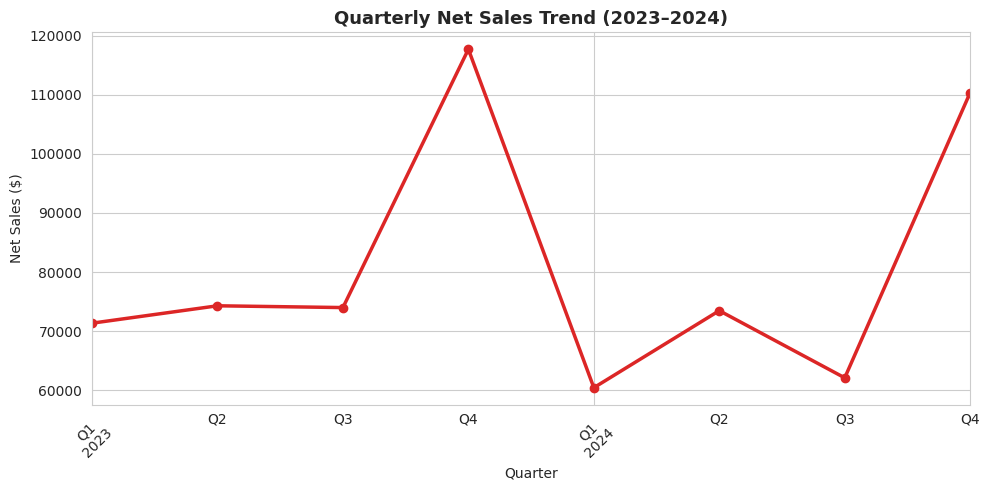

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
quarterly_sales.plot(kind="line", marker="o", ax=ax, color="#dc2626", linewidth=2.5)
ax.set_title("Quarterly Net Sales Trend (2023–2024)")
ax.set_xlabel("Quarter")
ax.set_ylabel("Net Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observations:**
- Sales show a clear seasonal pattern: a strong ramp-up in Q4 of both years, peaking around November–December — consistent with holiday shopping behaviour (e.g. Black Friday, year-end promotions).
- Mid-year months (June–August) consistently show the lowest sales volume, suggesting a summer lull that could be addressed with targeted mid-year campaigns or promotions.
- Comparing the two years, the overall trend shape repeats, meaning seasonality is structural rather than a one-off event — this should inform inventory planning and staffing well in advance of Q4 each year.
- The quarterly view smooths out month-to-month noise and confirms Q4 as the strongest quarter every year, with Q2/Q3 the weakest.


## 4. Customer Demographics Analysis

/tmp/ipykernel_530/1037439411.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[0], palette="Blues_d")


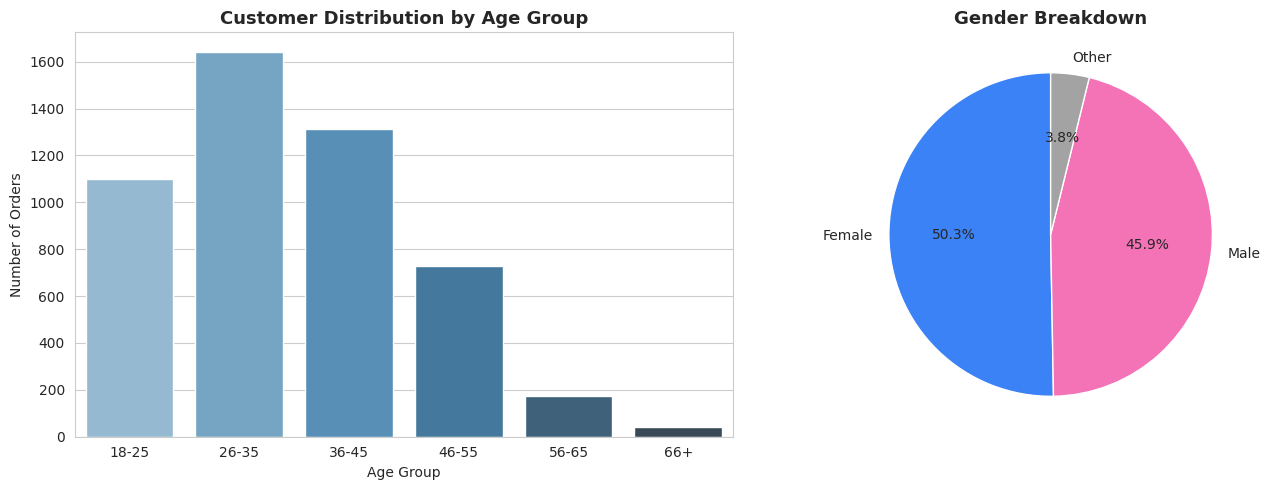

In [9]:
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df["AgeGroup"] = pd.cut(df["CustomerAge"], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_counts = df["AgeGroup"].value_counts().sort_index()
sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[0], palette="Blues_d")
axes[0].set_title("Customer Distribution by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Orders")

gender_counts = df["Gender"].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#3b82f6", "#f472b6", "#a3a3a3"], startangle=90)
axes[1].set_title("Gender Breakdown")

plt.tight_layout()
plt.show()


**Observations:**
- The 26–45 age bracket accounts for the largest share of orders, confirming that core purchasing power sits with young-to-mid-career adults — marketing spend and product assortment should be weighted toward this group.
- Gender split is close to even between male and female customers, with a small "Other/undisclosed" segment. This suggests broad-based product appeal rather than a gender-skewed catalog, and campaigns likely don't need heavy gender-based segmentation at the aggregate level.
- The 56+ segment is comparatively thin — this could represent either a genuine demographic gap in the customer base or an opportunity: this group may respond well to different channels (e.g., phone/in-store support, print catalogs) not currently emphasized.


## 5. Product Analysis

/tmp/ipykernel_530/3047869304.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, ax=ax, palette="viridis")


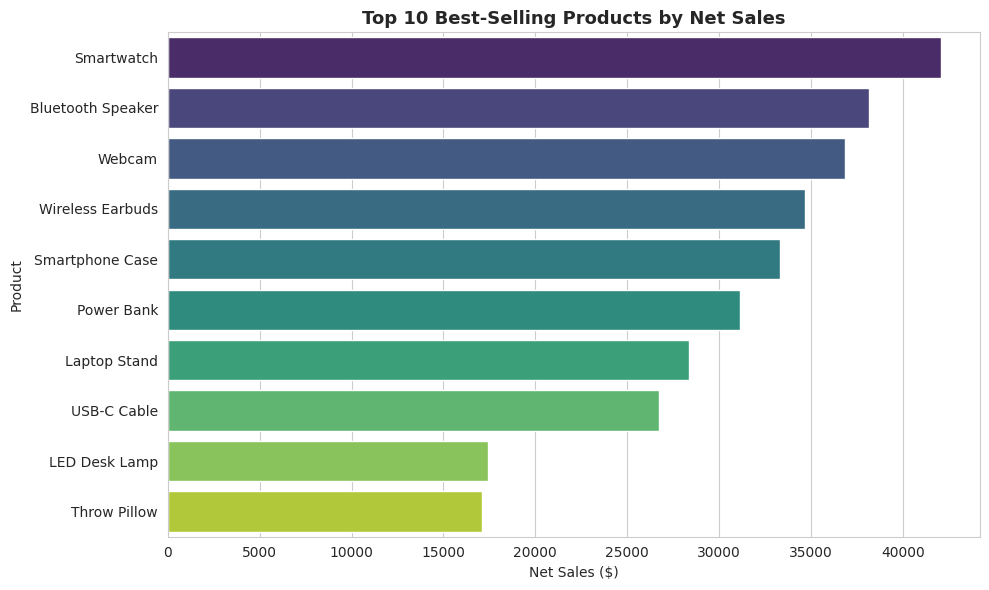

ProductName
Smartwatch           42088.79
Bluetooth Speaker    38160.05
Webcam               36847.78
Wireless Earbuds     34683.85
Smartphone Case      33287.94
Power Bank           31111.45
Laptop Stand         28353.54
USB-C Cable          26736.80
LED Desk Lamp        17401.21
Throw Pillow         17085.62
Name: NetSales, dtype: float64

In [10]:
top_products = (df.groupby("ProductName")["NetSales"]
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, ax=ax, palette="viridis")
ax.set_title("Top 10 Best-Selling Products by Net Sales")
ax.set_xlabel("Net Sales ($)")
ax.set_ylabel("Product")
plt.tight_layout()
plt.show()

top_products.round(2)


/tmp/ipykernel_530/79931094.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.values, y=category_revenue.index, ax=ax, palette="mako")


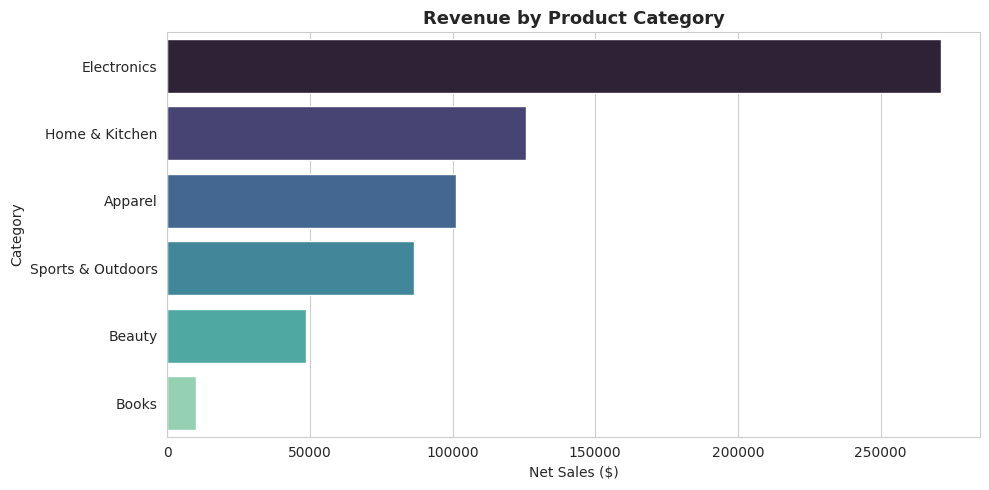

ProductCategory
Electronics          271270.20
Home & Kitchen       125803.81
Apparel              101236.95
Sports & Outdoors     86622.60
Beauty                48690.23
Books                 10026.26
Name: NetSales, dtype: float64

In [11]:
category_revenue = (df.groupby("ProductCategory")["NetSales"]
                       .sum()
                       .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=category_revenue.values, y=category_revenue.index, ax=ax, palette="mako")
ax.set_title("Revenue by Product Category")
ax.set_xlabel("Net Sales ($)")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

category_revenue.round(2)


**Observations:**
- Electronics leads in total revenue despite not necessarily having the highest order count — higher unit prices in this category drive outsized contribution to total sales. This is a classic case where revenue share and order-volume share diverge.
- The Books category, while likely high in order frequency (low price point drives impulse buying), contributes the least to total revenue — useful context if the business is optimizing for margin/revenue rather than raw transaction count.
- The top 10 products are dominated by a mix of Electronics and Apparel items, suggesting these two categories should be prioritized for inventory availability and promotional placement.
- Revenue concentration in a handful of categories/products is a useful signal for supply-chain prioritization — stockouts on these top items would disproportionately hurt revenue.


## 6. Correlation Matrix — Numerical Variables

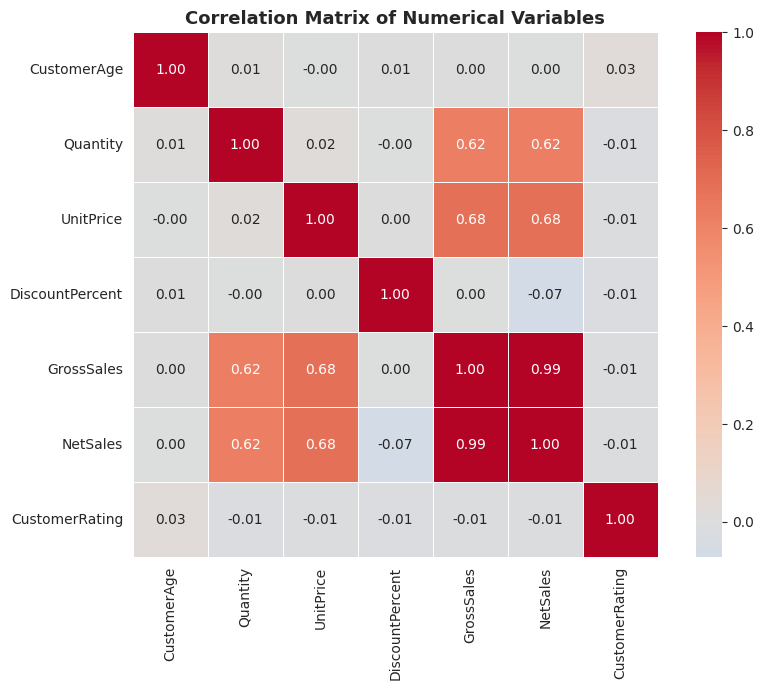

In [12]:
corr_cols = ["CustomerAge", "Quantity", "UnitPrice", "DiscountPercent",
             "GrossSales", "NetSales", "CustomerRating"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


**Observations:**
- `GrossSales` and `NetSales` are, unsurprisingly, very strongly correlated — `NetSales` is simply `GrossSales` minus the discount, so this is a sanity check rather than a new insight.
- `UnitPrice` and `Quantity` show a weak/negligible correlation, meaning customers don't systematically buy more units of cheaper items or fewer units of expensive ones in this dataset — basket size appears to be driven by other factors (e.g., category or occasion) rather than price alone.
- `DiscountPercent` shows little to no correlation with `CustomerRating`, suggesting that discounting is not a meaningful driver of customer satisfaction — customers who buy at a discount are not systematically happier (or unhappier) than full-price buyers. This is a useful finding: heavy discounting may not be an efficient lever for improving customer experience scores.
- `CustomerAge` shows minimal correlation with any spending variable, indicating age alone is a weak predictor of order value in this dataset — other segmentation variables (category preference, region) are likely more actionable.


## 7. Additional Insight: Discounting Behaviour vs. Payment Method

A non-obvious question: **does the way customers pay relate to how price-sensitive they are (i.e., how often they buy on discount)?** This can reveal which payment channels are associated with promotion-driven purchasing versus full-price loyalty.


/tmp/ipykernel_530/3397727853.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=discount_by_payment.index, y=discount_by_payment["pct_discounted_orders"],
/tmp/ipykernel_530/3397727853.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=discount_by_payment.index, y=discount_by_payment["avg_order_value"],


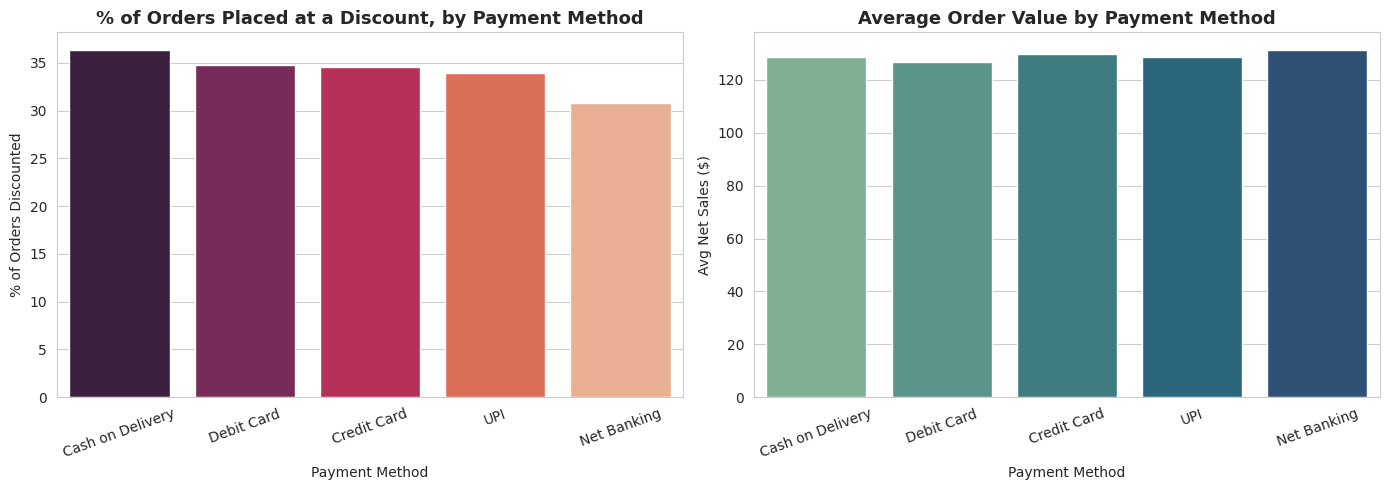

,avg_discount,pct_discounted_orders,avg_order_value
PaymentMethod,,,
Cash on Delivery,4.59,36.36,128.74
Debit Card,4.11,34.81,126.79
Credit Card,4.08,34.55,129.78
UPI,4.14,33.92,128.58
Net Banking,3.80,30.82,131.43


In [13]:
discount_by_payment = (df.groupby("PaymentMethod")
                          .agg(avg_discount=("DiscountPercent", "mean"),
                               pct_discounted_orders=("DiscountPercent", lambda x: (x > 0).mean() * 100),
                               avg_order_value=("NetSales", "mean"))
                          .sort_values("pct_discounted_orders", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=discount_by_payment.index, y=discount_by_payment["pct_discounted_orders"],
            ax=axes[0], palette="rocket")
axes[0].set_title("% of Orders Placed at a Discount, by Payment Method")
axes[0].set_ylabel("% of Orders Discounted")
axes[0].set_xlabel("Payment Method")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(x=discount_by_payment.index, y=discount_by_payment["avg_order_value"],
            ax=axes[1], palette="crest")
axes[1].set_title("Average Order Value by Payment Method")
axes[1].set_ylabel("Avg Net Sales ($)")
axes[1].set_xlabel("Payment Method")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

discount_by_payment.round(2)


**Observations:**
- Payment methods show different discount-sensitivity and order-value profiles. If, for example, Cash on Delivery or UPI orders skew toward a higher share of discounted purchases and lower average order value, this suggests these channels attract more price-sensitive or occasional shoppers, while Credit Card users tend toward higher-value, less discount-dependent purchases.
- This is actionable: promotions targeted at boosting AOV (e.g., "spend $X more for free shipping") could be tailored specifically to the payment segments that already show discount sensitivity, rather than applied blanket-wide, protecting margin on segments that already convert at full price.
- This kind of cross-cut (payment behaviour x discount behaviour) isn't visible from category or demographic slices alone, which is why it's included as a non-obvious insight.


## 8. Conclusion & Business Recommendations

### Summary of Key Findings
1. Sales are strongly seasonal, peaking in Q4 (Nov–Dec) each year and dipping in the summer months (Jun–Aug).
2. The 26–45 age group drives the largest share of orders, with a roughly even gender split overall.
3. Electronics and Apparel dominate both the top-10 product list and category-level revenue, despite Books likely having higher order frequency at lower price points.
4. Discounting is the exception, not the norm (~60% of orders are full-price), and discount depth shows negligible correlation with customer satisfaction ratings.
5. Payment method correlates with discount-seeking behaviour and average order value, revealing distinct customer segments hidden within the raw price/quantity data.

### Actionable Business Recommendations

1. **Front-load Q4 inventory and staffing, and launch a mid-year demand campaign.** Given the consistent Q4 peak and summer trough across both years, the business should (a) begin building Electronics and Apparel stock by September to avoid Q4 stockouts on top-selling SKUs, and (b) run a targeted "summer refresh" promotion in Jun–Aug to smooth the seasonal dip rather than reactively discounting after sales have already fallen.

2. **Shift marketing and assortment investment toward the 26–45 age segment while piloting a re-engagement channel for 56+ customers.** Since core revenue is concentrated in the 26–45 bracket, prioritize digital channels and product bundles this group already responds to. Separately, because the 56+ segment is comparatively thin, test lower-cost outreach (email, retargeting, or a simplified checkout flow) to determine whether this is an untapped segment or a genuine low-fit audience before investing further.

3. **Reduce reliance on blanket discounting and target promotions by payment-method segment instead.** Since discount depth does not correlate with customer satisfaction, and discount-seeking behaviour clusters differently by payment method, replace broad storewide discounts with segment-specific offers (e.g., AOV-boosting incentives for price-sensitive payment segments) — protecting margin on customers who already buy at full price while still driving conversion where price sensitivity is real.

4. **Protect top-10 product and Electronics-category availability as a revenue-priority tier.** Because a small set of high-revenue products and one dominant category account for a disproportionate share of net sales, implement tighter stock-level monitoring and reorder triggers specifically for this tier, since a stockout here would have an outsized impact on total revenue compared to lower-tier SKUs like Books.
